# Ejercicio 01/02

Se escogió el problema de los ingenieros, en donde un robot tiene que entregar galletas a un grupo de ingenieros en una habitación cuadrada.

Lo primero que se realiza es importar las librerias necesarias. Random para toda la generación de población aleatoria, collections para colas, numpy para calculos eficientes y matplotlib para graficar.

In [67]:
import random
import collections
import numpy as np
import matplotlib.pyplot as plt

## Terminales

Lo siguiente es definir la ubicación de los ingenieros. Para eso se define el tamaño de la habitación (25x25), el número de los ingenieros (8) y la semilla, que se usa para la generación de números aleatorios, en este caso, 5.

Para programación genética, los terminales del ejercicio son los índices de los ingenieros. Así, las hojas de los árboles siempre serán la "entrega de una galleta" al ingeniero $i$.

[(19, 8), (23, 11), (25, 22), (23, 20), (16, 0), (14, 24), (7, 20), (1, 5)]


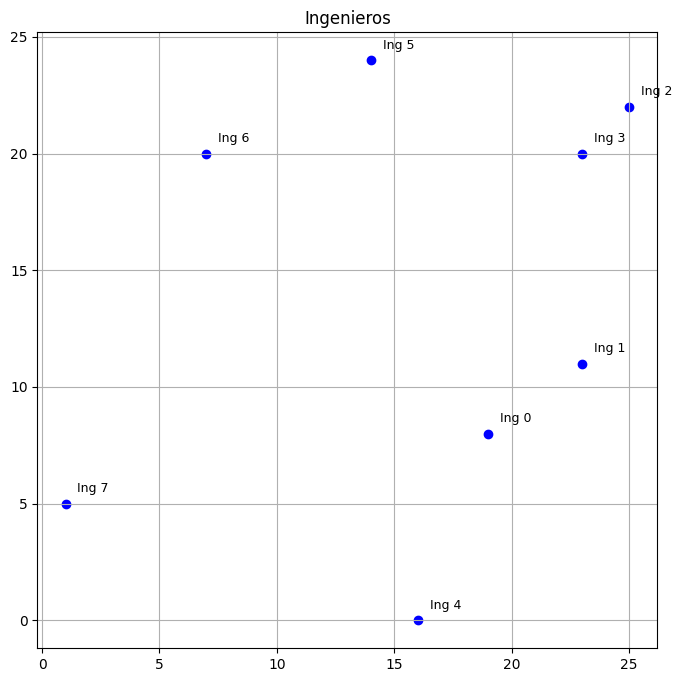

In [68]:
W = 25
H = 25
N = 8
SEED = 5

random.seed(SEED)
ingenieros = [(random.randint(0,W), random.randint(0,H)) for _ in range(N)]
print(ingenieros)

x_coords = [ingenieros[i][0] for i in range(len(ingenieros))]
y_coords = [ingenieros[i][1] for i in range(len(ingenieros))]

plt.figure(figsize=(8, 8))
plt.scatter(x_coords, y_coords, marker='o', linestyle='-', color='blue')

for i, (x, y) in enumerate(ingenieros):
    plt.text(x + 0.5, y + 0.5, f'Ing {i}', fontsize=9)

plt.title('Ingenieros')
plt.grid(True)
plt.show()

## Funciones

Las funciones del programa genético son:
- PROGN2: que tiene como hijos 2 funciones y sirve para formar la estructura de arbol
- VISITAR: es la función donde se simula el robot visitando a uno de los ingenieros para entregar una galleta

In [69]:
def distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

class Node:
    def __init__(self, value, children=None):
        self.value = value
        self.children = children if children is not None else []

    def __repr__(self):
        if not self.children:
            return str(self.value)
        return f"{self.value}({', '.join(map(str, self.children))})"

FUNCTIONS = {
    'PROG2': {'arity': 2},
    'VISITAR': {'arity': 1}
}
TERMINALS = list(range(N))

## Árboles


Esta sección del código define los árboles aleatorios, cada uno generado inicialmente aleatoriamente, y luego cruzado de generación en generación hasta obtener un resultado.

In [70]:
def generate_random_tree(max_depth, current_depth=0):
    if current_depth == max_depth or (current_depth > 0 and random.random() < 0.3):
        return Node(random.choice(TERMINALS))
    else:
        function_name = random.choice(list(FUNCTIONS.keys()))
        func_info = FUNCTIONS[function_name]
        children = []
        for _ in range(func_info['arity']):
            children.append(generate_random_tree(max_depth, current_depth + 1))
        return Node(function_name, children)

def get_random_node_and_parent(tree_root):
    nodes_with_parents = []

    queue = collections.deque([(tree_root, None)]) # (node, parent)

    while queue:
        current_node, parent_node = queue.popleft()
        nodes_with_parents.append((current_node, parent_node))

        for child in current_node.children:
            queue.append((child, current_node))

    return random.choice(nodes_with_parents)

def copy_tree(node):
    if node is None:
        return None
    return Node(node.value, [copy_tree(child) for child in node.children])

def crossover_trees(parent1_tree, parent2_tree):
    child1_tree = copy_tree(parent1_tree)
    child2_tree = copy_tree(parent2_tree)

    node1_to_swap, parent1_of_node1 = get_random_node_and_parent(child1_tree)
    node2_to_swap, parent2_of_node2 = get_random_node_and_parent(child2_tree)

    if parent1_of_node1:
        idx1 = parent1_of_node1.children.index(node1_to_swap)
        parent1_of_node1.children[idx1] = node2_to_swap
    else:
        child1_tree = node2_to_swap

    if parent2_of_node2:
        idx2 = parent2_of_node2.children.index(node2_to_swap)
        parent2_of_node2.children[idx2] = node1_to_swap
    else:
        child2_tree = node1_to_swap

    return child1_tree, child2_tree

def mutate_tree(tree, max_depth, mutation_rate):
    mutated_tree = copy_tree(tree)
    if random.random() < mutation_rate:
        node_to_mutate, parent_of_node = get_random_node_and_parent(mutated_tree)

        new_subtree = generate_random_tree(max_depth=max_depth, current_depth=0)

        if parent_of_node:
            idx = parent_of_node.children.index(node_to_mutate)
            parent_of_node.children[idx] = new_subtree
        else:
            mutated_tree = new_subtree
    return mutated_tree

def evaluate_tree(node, initial_robot_pos_idx, points_per_cookie=100, ingenieros_coords=ingenieros):
    total_distance = 0
    total_points = 0
    path_sequence = []
    current_visited_engineers = set()

    def _evaluate_recursive(sub_node, current_robot_pos_idx_internal):
        nonlocal total_distance, total_points, path_sequence

        if sub_node.value in FUNCTIONS:
            if sub_node.value == 'PROG2':
                last_pos_after_child1 = _evaluate_recursive(sub_node.children[0], current_robot_pos_idx_internal)
                last_pos_after_child2 = _evaluate_recursive(sub_node.children[1], last_pos_after_child1)

                return last_pos_after_child2

            elif sub_node.value == 'VISITAR':
                engineer_to_visit_idx = _evaluate_recursive(sub_node.children[0], current_robot_pos_idx_internal)

                if isinstance(engineer_to_visit_idx, int) and 0 <= engineer_to_visit_idx < len(ingenieros_coords):
                    move_dist = distance(ingenieros_coords[current_robot_pos_idx_internal], ingenieros_coords[engineer_to_visit_idx])
                    total_distance += move_dist

                    if engineer_to_visit_idx not in current_visited_engineers:
                        total_points += points_per_cookie
                        current_visited_engineers.add(engineer_to_visit_idx)

                    path_sequence.append(engineer_to_visit_idx)
                    return engineer_to_visit_idx
                else:
                    return current_robot_pos_idx_internal
        else:
            return sub_node.value

    final_robot_pos_idx = _evaluate_recursive(node, initial_robot_pos_idx)
    fitness = total_distance - total_points

    return fitness, total_distance, total_points, path_sequence, final_robot_pos_idx

## Algoritmo

Esta última sección es todo lo relacionado a la programación Genética. Incluye la función de selección, constantes, y el bucle principal de la simulación


--- Ejecutando Algoritmo de Programación Genética ---

--- Resultados Finales de Programación Genética ---
Mejor programa encontrado (árbol): PROG2(PROG2(VISITAR(VISITAR(0)), 6), VISITAR(PROG2(4, PROG2(PROG2(PROG2(PROG2(5, VISITAR(VISITAR(PROG2(PROG2(4, VISITAR(4)), PROG2(5, VISITAR(PROG2(4, 5))))))), 5), PROG2(PROG2(PROG2(PROG2(4, PROG2(PROG2(PROG2(4, PROG2(6, PROG2(4, PROG2(7, 3)))), PROG2(PROG2(VISITAR(3), PROG2(7, 4)), 4)), PROG2(4, PROG2(7, 3)))), PROG2(PROG2(VISITAR(3), PROG2(PROG2(VISITAR(3), PROG2(5, 4)), 4)), 4)), PROG2(5, VISITAR(VISITAR(PROG2(PROG2(4, 0), PROG2(PROG2(VISITAR(PROG2(7, PROG2(4, 1))), 5), PROG2(4, 5))))))), 0)), PROG2(3, PROG2(PROG2(4, PROG2(7, 3)), PROG2(PROG2(PROG2(PROG2(PROG2(PROG2(5, PROG2(4, VISITAR(4))), 5), PROG2(PROG2(PROG2(5, VISITAR(VISITAR(PROG2(PROG2(PROG2(4, VISITAR(4)), VISITAR(4)), PROG2(5, VISITAR(PROG2(5, VISITAR(PROG2(4, 5))))))))), 5), 7)), PROG2(VISITAR(7), 3)), VISITAR(2)), 6)))))))
Mejor Fitness Score: -792.17
Distancia recorrida: 7.83
Ga

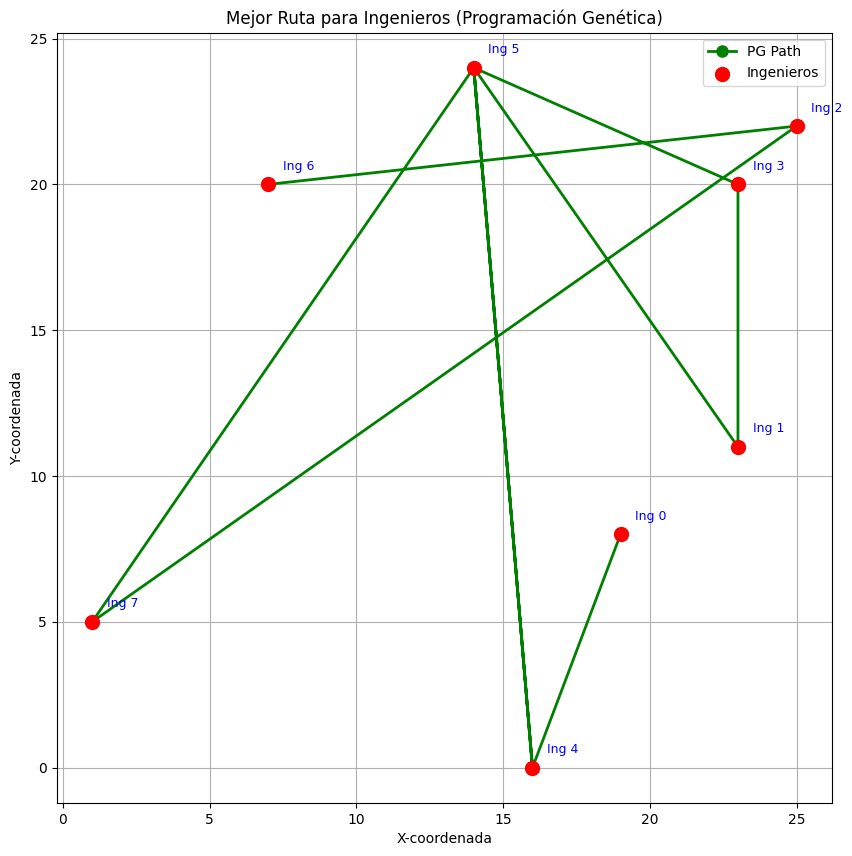

In [71]:
def select_parents_pg(population, fitness_scores, tournament_size=5):
    competitors_indices = random.sample(range(len(population)), tournament_size)
    winner_idx = min(competitors_indices, key=lambda idx: fitness_scores[idx])
    return winner_idx

print("\n--- Ejecutando Algoritmo de Programación Genética ---")

pg_population_size = 200   # Increased population size for better exploration
pg_num_generations = 100   # Adjusted generations
pg_mutation_rate   = 0.15  # Slightly higher mutation rate
pg_crossover_rate  = 0.9   # High crossover rate
pg_max_tree_depth  = 5     # Max depth for initial population and mutation

# Initialize population (forest) of random trees
pg_population = [generate_random_tree(pg_max_tree_depth) for _ in range(pg_population_size)]

best_pg_program = None
best_pg_fitness = float('inf')
best_pg_program_data = (0, 0, [], 0)

initial_robot_start_idx = 0 # This is the index of the engineer where the robot *starts* its journey

for generation in range(pg_num_generations):
    pg_fitness_scores = []
    current_generation_evaluated_data = []

    for program_tree in pg_population:
        fitness, evaluated_distance, points, path_sequence, final_pos = evaluate_tree(program_tree, initial_robot_start_idx)
        pg_fitness_scores.append(fitness)
        current_generation_evaluated_data.append((evaluated_distance, points, path_sequence, final_pos))

    current_best_idx = np.argmin(pg_fitness_scores)
    current_best_fitness = pg_fitness_scores[current_best_idx]

    if current_best_fitness < best_pg_fitness:
        best_pg_fitness = current_best_fitness
        best_pg_program = pg_population[current_best_idx]
        best_pg_program_data = current_generation_evaluated_data[current_best_idx]

    next_pg_population = []
    while len(next_pg_population) < pg_population_size:
        parent1_idx = select_parents_pg(pg_population, pg_fitness_scores)
        parent2_idx = select_parents_pg(pg_population, pg_fitness_scores)

        parent1 = pg_population[parent1_idx]
        parent2 = pg_population[parent2_idx]

        offspring1, offspring2 = copy_tree(parent1), copy_tree(parent2) # Start with copies

        if random.random() < pg_crossover_rate:
            offspring1, offspring2 = crossover_trees(parent1, parent2)

        # Apply mutation (after potential crossover)
        offspring1 = mutate_tree(offspring1, pg_max_tree_depth, pg_mutation_rate)
        offspring2 = mutate_tree(offspring2, pg_max_tree_depth, pg_mutation_rate)

        next_pg_population.append(offspring1)
        if len(next_pg_population) < pg_population_size:
            next_pg_population.append(offspring2)

    pg_population = next_pg_population

print("\n--- Resultados Finales de Programación Genética ---")
print(f"Mejor programa encontrado (árbol): {best_pg_program}")
print(f"Mejor Fitness Score: {best_pg_fitness:.2f}")

best_distance_pg, best_points_pg, best_path_sequence_pg, _ = best_pg_program_data

print(f"Distancia recorrida: {best_distance_pg:.2f}")
points_per_cookie_val = 100
print(f"Galletas entregadas: {best_points_pg / points_per_cookie_val}")

if best_path_sequence_pg:
    plot_x = []
    plot_y = []

    plot_x.append(ingenieros[initial_robot_start_idx][0])
    plot_y.append(ingenieros[initial_robot_start_idx][1])

    current_plotting_pos_idx = initial_robot_start_idx

    for engineer_idx in best_path_sequence_pg:
        if engineer_idx != current_plotting_pos_idx:
            plot_x.append(ingenieros[engineer_idx][0])
            plot_y.append(ingenieros[engineer_idx][1])
            current_plotting_pos_idx = engineer_idx

    plt.figure(figsize=(10, 10))
    plt.plot(plot_x, plot_y, marker='o', linestyle='-', color='green', linewidth=2, markersize=8, label='PG Path')
    plt.scatter([p[0] for p in ingenieros], [p[1] for p in ingenieros], color='red', s=100, zorder=5, label='Ingenieros') # Mark all engineers

    for i, (x, y) in enumerate(ingenieros):
        plt.text(x + 0.5, y + 0.5, f'Ing {i}', fontsize=9, color='blue')

    plt.title('Mejor Ruta para Ingenieros (Programación Genética)')
    plt.xlabel('X-coordenada')
    plt.ylabel('Y-coordenada')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("El mejor programa PG no generó ninguna secuencia de visitas.")